# Unemployment-rate ranking CIs

Same procedure as `NGDP_CI`, but for the SPF unemployment-rate panel:
- **Forecasts**: `SPFmicrodata.xlsx`, sheet `UNEMP` (UNEMP1..UNEMP6).
- **Realizations**: `rucQvMd.xlsx` — monthly RTDSM vintage matrix; we average each quarter's three months to get the quarterly UR.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from rankci import (
    rank_ci_stepwise_pairwise,
    rank_ci_marginal_pairwise,
    rank_confidence_intervals_simulation_pairwise,
    rank_ci_stepwise_simulation_pairwise,
    rank_ci_marginal_simulation_pairwise,
    compute_pairwise,
    load_spf,
    load_rtdsm,
    compute_errors,
    compute_error_panel,
    select_top_forecasters,
    winsorize_panel,
)
from rankci.data import advance_vintage_col, get_advance_estimate

# Data Loading

In [2]:
df = load_spf("../data/SPFmicrodata.xlsx", sheet="UNEMP")
print(f"SPF UNEMP: {df.shape[0]} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()

SPF UNEMP: 9145 rows × 14 columns
Columns: ['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'UNEMP1', 'UNEMP2', 'UNEMP3', 'UNEMP4', 'UNEMP5', 'UNEMP6', 'UNEMPA', 'UNEMPB', 'UNEMPC', 'UNEMPD']


/Users/Parimah/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,YEAR,QUARTER,ID,INDUSTRY,UNEMP1,UNEMP2,UNEMP3,UNEMP4,UNEMP5,UNEMP6,UNEMPA,UNEMPB,UNEMPC,UNEMPD
0,1968,4,1,NaN,3.6,3.7,4.0,4.0,3.7,3.7,NaN,NaN,NaN,NaN
1,1968,4,2,NaN,3.6,3.5,3.5,3.5,3.6,3.6,NaN,NaN,NaN,NaN
2,1968,4,3,NaN,3.6,3.7,3.9,4.2,4.2,4.1,NaN,NaN,NaN,NaN
3,1968,4,4,NaN,3.6,3.8,4.0,4.2,4.0,4.0,NaN,NaN,NaN,NaN
4,1968,4,5,NaN,3.6,3.6,3.7,3.9,3.7,3.7,NaN,NaN,NaN,NaN


In [3]:
# Monthly RTDSM, averaged into quarterly observations under the hood
ruc = load_rtdsm("../data/rucQvMd.xlsx", prefix="RUC", freq="monthly")
print(f"RTDSM (RUC): {ruc.shape[0]} quarters × {ruc.shape[1]} vintages")
ruc.head()

RTDSM (RUC): 317 quarters × 242 vintages


RUC65Q4   RUC66Q1   RUC66Q2   RUC66Q3   RUC66Q4   RUC67Q1  \
YEAR QUARTER                                                              
1947 1            NaN       NaN       NaN       NaN       NaN       NaN   
     2            NaN       NaN       NaN       NaN       NaN       NaN   
     3            NaN       NaN       NaN       NaN       NaN       NaN   
     4            NaN       NaN       NaN       NaN       NaN       NaN   
1948 1            NaN  3.766667  3.766667  3.766667  3.766667  3.733333   

               RUC67Q2   RUC67Q3   RUC67Q4   RUC68Q1  ...   RUC23Q4   RUC24Q1  \
YEAR QUARTER                                          ...                       
1947 1             NaN       NaN       NaN       NaN  ...       NaN       NaN   
     2             NaN       NaN       NaN       NaN  ...       NaN       NaN   
     3             NaN       NaN       NaN       NaN  ...       NaN       NaN   
     4             NaN       NaN       NaN       NaN  ...       NaN       NaN   
1948 1        3.733333  3.733333  3.733333  3.733333  ...  3.733333  3.733333   

               RUC24Q2   RUC24Q3   RUC24Q4   RUC25Q1   RUC25Q2   RUC25Q3  \
YEAR QUARTER                                                               
1947 1             NaN       NaN       NaN       NaN       NaN       NaN   
     2             NaN       NaN       NaN       NaN       NaN       NaN   
     3             NaN       NaN       NaN       NaN       NaN       NaN   
     4             NaN       NaN       NaN       NaN       NaN       NaN   
1948 1        3.733333  3.733333  3.733333  3.733333  3.733333  3.733333   

               RUC25Q4   RUC26Q1  
YEAR QUARTER                      
1947 1             NaN       NaN  
     2             NaN       NaN  
     3             NaN       NaN  
     4             NaN       NaN  
1948 1        3.733333  3.733333  

[5 rows x 242 columns]

# Sanity Checks

In [4]:
# Verify advance UR estimates for a few known quarters
test_cases = [(1995, 2), (2008, 4), (2020, 2)]
print(f"{'Target Quarter':<20} {'Vintage Col':<14} {'UR (%)'}")
print("-" * 50)
for y, q in test_cases:
    col = advance_vintage_col(y, q, prefix="RUC")
    val = get_advance_estimate(y, q, ruc)
    print(f"  {y}:Q{q:<16}  {col:<14}  {val:.2f}")

Target Quarter       Vintage Col    UR (%)
--------------------------------------------------
  1995:Q2                 RUC95Q3         5.70
  2008:Q4                 RUC09Q1         6.87
  2020:Q2                 RUC20Q3         13.03


# Forecast Errors

In [5]:
errors_df = compute_errors(df, ruc, indicator="UNEMP")

print("Error summary by horizon (percentage points):")
for h in range(1, 7):
    col = f"error_UNEMP{h}"
    if col in errors_df.columns:
        print(f"  {col}: mean={errors_df[col].mean():+.2f}, "
              f"std={errors_df[col].std():.2f}, "
              f"nan%={errors_df[col].isna().mean()*100:.1f}%")

errors_df.head()

Error summary by horizon (percentage points):
  error_UNEMP1: mean=-0.00, std=0.05, nan%=4.5%
  error_UNEMP2: mean=+0.06, std=0.36, nan%=4.3%
  error_UNEMP3: mean=+0.04, std=0.88, nan%=4.4%
  error_UNEMP4: mean=-0.01, std=1.06, nan%=4.8%
  error_UNEMP5: mean=-0.07, std=1.16, nan%=5.5%
  error_UNEMP6: mean=-0.10, std=1.30, nan%=10.5%


,YEAR,QUARTER,ID,INDUSTRY,error_UNEMP1,error_UNEMP2,error_UNEMP3,error_UNEMP4,error_UNEMP5,error_UNEMP6
0,1968,4,1,NaN,0.0,0.266667,0.666667,0.533333,4.440892e-16,0.1
1,1968,4,2,NaN,0.0,0.066667,0.166667,0.033333,-1.000000e-01,0.0
2,1968,4,3,NaN,0.0,0.266667,0.566667,0.733333,5.000000e-01,0.5
3,1968,4,4,NaN,0.0,0.366667,0.666667,0.733333,3.000000e-01,0.4
4,1968,4,5,NaN,0.0,0.166667,0.366667,0.433333,4.440892e-16,0.1


In [6]:
# Squared error panel for UNEMP3 (one-quarter-ahead)
X_wide = compute_error_panel(df, ruc, indicator="UNEMP", horizon=3, metric="squared")
print(f"Panel shape: {X_wide.shape[0]} quarters × {X_wide.shape[1]} forecasters")
X_wide.head()

Panel shape: 228 quarters × 353 forecasters


ID                 1         2         3         4         5         6    \
YEAR QUARTER                                                               
1968 4        0.444444  0.027778  0.321111  0.444444  0.134444  0.134444   
1969 1             NaN  0.111111  0.284444  0.537778       NaN  0.111111   
     2        0.090000       NaN  0.010000  0.040000       NaN  0.090000   
     3        0.250000       NaN  0.640000       NaN       NaN  0.360000   
     4        0.217778       NaN  0.054444  0.017778       NaN  0.017778   

ID                 7         8         9             10   ...  600  601  602  \
YEAR QUARTER                                              ...                  
1968 4             NaN  0.934444  0.217778  7.111111e-02  ...  NaN  NaN  NaN   
1969 1        0.001111  0.054444  0.187778  5.444444e-02  ...  NaN  NaN  NaN   
     2             NaN  0.010000  0.010000  1.972152e-31  ...  NaN  NaN  NaN   
     3             NaN       NaN       NaN  1.000000e-02  ...  NaN  NaN  NaN   
     4        0.001111  0.027778  0.001111           NaN  ...  NaN  NaN  NaN   

ID            603  604  605  606  607  608  609  
YEAR QUARTER                                     
1968 4        NaN  NaN  NaN  NaN  NaN  NaN  NaN  
1969 1        NaN  NaN  NaN  NaN  NaN  NaN  NaN  
     2        NaN  NaN  NaN  NaN  NaN  NaN  NaN  
     3        NaN  NaN  NaN  NaN  NaN  NaN  NaN  
     4        NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 353 columns]

# Forecaster Selection

In [7]:
obs_counts = X_wide.notna().sum()
mean_mse = X_wide.mean()

stats = pd.DataFrame({
    "obs_count": obs_counts,
    "mean_mse":  mean_mse,
    "rmse":      np.sqrt(mean_mse),
}).sort_values("obs_count", ascending=False)

print(f"Total forecasters: {len(stats)}")
print(f"Forecasters with >= 20 obs: {(stats['obs_count'] >= 20).sum()}")
print(f"Forecasters with >= 50 obs: {(stats['obs_count'] >= 50).sum()}")
stats.head(20)

Total forecasters: 353
Forecasters with >= 20 obs: 151
Forecasters with >= 50 obs: 56


,obs_count,mean_mse,rmse
ID,,,
65,124,0.204588,0.452314
433,123,1.047613,1.023530
426,122,1.383925,1.176403
421,122,1.331296,1.153818
84,122,0.148552,0.385424
428,120,0.867591,0.931446
411,118,1.879562,1.370971
463,106,0.947197,0.973240
510,105,1.116619,1.056702


In [8]:
N = 8
X_panel = select_top_forecasters(X_wide, N=N, min_obs=20)
print(f"Selected {X_panel.shape[1]} forecasters, {X_panel.shape[0]} quarters")
print(f"Forecaster IDs: {X_panel.columns.tolist()}")

Selected 8 forecasters, 228 quarters
Forecaster IDs: [65, 433, 84, 421, 426, 428, 411, 463]


# Rank Confidence Intervals

In [9]:
X = X_panel.values
population_ids = X_panel.columns.tolist()

out = rank_ci_stepwise_pairwise(X, alpha=0.05, B=5000, seed=42)

results = pd.DataFrame({
    "ID":         population_ids,
    "MSE":        out["theta_hat"].round(4),
    "RMSE":       np.sqrt(out["theta_hat"]).round(4),
    "CI_lower":   out["rank_ci"][:, 0],
    "CI_upper":   out["rank_ci"][:, 1],
}).sort_values("MSE")
results.index = range(1, len(results) + 1)
results.index.name = "Rank"
results

=== Pairwise shared observations ===
  Min: 44, Mean: 81.4, Max: 108
  Pairs with < 20 shared obs: 0

=== Test statistics (delta_hat / se) ===
  Max: 4.0321, Pairs with t > 1.96: 8


,ID,MSE,RMSE,CI_lower,CI_upper
Rank,,,,,
1,84,0.1486,0.3854,1,8
2,65,0.2046,0.4523,1,8
3,428,0.8676,0.9314,1,8
4,463,0.9472,0.9732,1,8
5,433,1.0476,1.0235,1,8
6,421,1.3313,1.1538,1,8
7,426,1.3839,1.1764,1,8
8,411,1.8796,1.3710,1,8


# Worst-Quarter Inspection

Time coverage: (1968, 4) to (2025, 3) (228 quarters)

Top 10 quarters with highest average squared error:
YEAR  QUARTER
2020  1          90.576840
      2          31.486234
      3          18.162778
1974  4           2.636111
2020  4           1.406469
1980  3           1.210000
2008  4           1.106216
      3           1.082639
1982  3           1.024444
1980  1           1.000000
dtype: float64


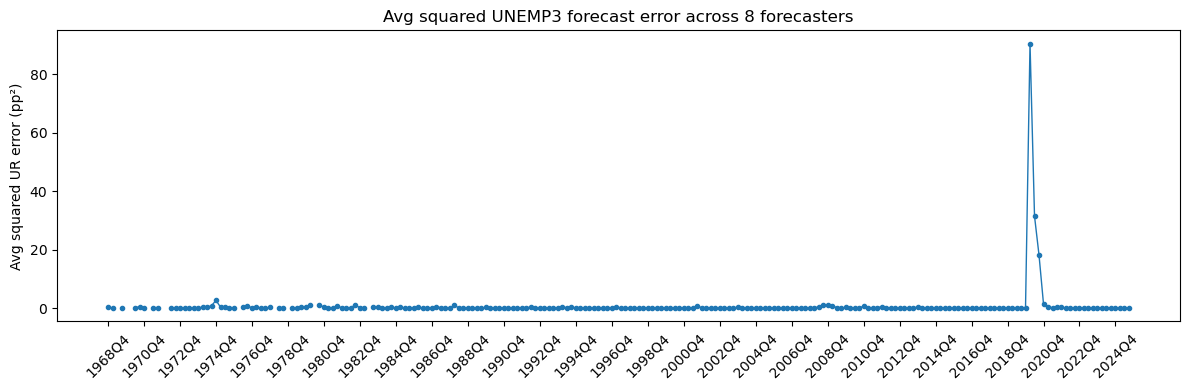

In [10]:
period_mse = X_panel.mean(axis=1)

print(f"Time coverage: {X_panel.index[0]} to {X_panel.index[-1]} ({len(X_panel)} quarters)\n")
print("Top 10 quarters with highest average squared error:")
print(period_mse.nlargest(10))

n = len(X_panel)
plt.figure(figsize=(12, 4))
plt.plot(range(n), period_mse, marker="o", linewidth=1, markersize=3)
plt.xticks(
    ticks=range(0, n, 8),
    labels=[f"{y}Q{q}" for y, q in X_panel.index[::8]],
    rotation=45,
)
plt.ylabel("Avg squared UR error (pp²)")
plt.title(f"Avg squared UNEMP3 forecast error across {N} forecasters")
plt.tight_layout()
plt.show()

# Winsorization (variant 2: pairwise differences)

In [11]:
print("=== Winsorize pairwise differences ===")
print(f"{'winsor_pct':<12} {'max_t':<10} {'mean CI width':<16}")
print("-" * 40)
for winsor_pct in [99, 97, 95, 90]:
    delta_w, se_w, _ = compute_pairwise(X, se_method="nw", winsor_pct=winsor_pct)
    t_vals = (delta_w / se_w)[~np.isnan(se_w)]

    out_w = rank_ci_stepwise_pairwise(
        X, alpha=0.05, B=1000, seed=42, winsor_pct=winsor_pct, verbose=False,
    )
    widths = out_w["rank_ci"][:, 1] - out_w["rank_ci"][:, 0]

    print(f"  {winsor_pct:<10} {t_vals.max():<10.3f} {widths.mean():<16.2f}")

=== Winsorize pairwise differences ===
winsor_pct   max_t      mean CI width   
----------------------------------------
  99         4.220      7.00            
  97         4.510      7.00            
  95         4.938      7.00            
  90         5.547      7.00            


# Marginal Rank Confidence Intervals

Per-forecaster CIs that control coverage marginally (no joint family-wise error control).

In [15]:
out_marg = rank_ci_marginal_pairwise(X, alpha=0.1, B=5000, seed=42)

results_marg = pd.DataFrame({
    "ID":       population_ids,
    "MSE":      out_marg["theta_hat"].round(4),
    "RMSE":     np.sqrt(out_marg["theta_hat"]).round(4),
    "cv_j":     out_marg["critical_values"].round(3),
    "CI_lower": out_marg["rank_ci"][:, 0],
    "CI_upper": out_marg["rank_ci"][:, 1],
}).sort_values("MSE")
results_marg.index = range(1, len(results_marg) + 1)
results_marg.index.name = "Rank"
results_marg

,ID,MSE,RMSE,cv_j,CI_lower,CI_upper
Rank,,,,,,
1,84,0.1486,0.3854,2.597,1,6
2,65,0.2046,0.4523,2.125,6,8
3,428,0.8676,0.9314,2.653,1,7
4,463,0.9472,0.9732,2.430,1,8
5,433,1.0476,1.0235,2.671,1,7
6,421,1.3313,1.1538,3.344,1,8
7,426,1.3839,1.1764,3.937,1,7
8,411,1.8796,1.3710,3.062,1,8


# Sensitivity to NW bandwidth `L`

Sweep `L ∈ {auto, 1, 2, 4, 8, 20}` for the marginal procedure.

In [13]:
L_values = [None, 1, 2, 4, 8, 20]

ci_by_L = {}
maxt_by_L = {}
for L in L_values:
    delta, se, _ = compute_pairwise(X, se_method="nw", L=L)
    maxt_by_L[L] = float(np.nanmax(delta / se))
    out_L = rank_ci_marginal_pairwise(X, alpha=0.05, B=2000, seed=42, L=L)
    ci_by_L[L] = out_L["rank_ci"]

order = np.argsort(out_marg["theta_hat"])
ordered_ids = [population_ids[i] for i in order]

table_L = pd.DataFrame(
    {
        f"L={L if L is not None else 'auto'}":
            [f"[{ci_by_L[L][i, 0]},{ci_by_L[L][i, 1]}]" for i in order]
        for L in L_values
    },
    index=ordered_ids,
)
table_L.index.name = "ID"

print("max test stat by L:")
for L, t in maxt_by_L.items():
    label = "auto" if L is None else str(L)
    print(f"  L={label:<5}  max_t = {t:.3f}")
print()
table_L

max test stat by L:
  L=auto   max_t = 4.032
  L=1      max_t = 4.238
  L=2      max_t = 4.039
  L=4      max_t = 4.194
  L=8      max_t = 4.235
  L=20     max_t = 5.589



,L=auto,L=1,L=2,L=4,L=8,L=20
ID,,,,,,
84,"[1,6]","[1,6]","[1,6]","[1,6]","[1,6]","[1,7]"
65,"[6,8]","[6,8]","[6,8]","[6,8]","[6,8]","[5,8]"
428,"[1,7]","[1,7]","[1,7]","[1,7]","[1,7]","[1,7]"
463,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
433,"[1,7]","[1,7]","[1,7]","[1,7]","[1,7]","[1,7]"
421,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
426,"[1,8]","[1,7]","[1,7]","[1,8]","[1,8]","[1,8]"
411,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,7]"


# MAE-based ranking

In [14]:
N      = 5
alpha  = 0.2
L      = None

# MAE
X_mae_wide  = compute_error_panel(df, ruc, indicator="UNEMP", horizon=3, metric="absolute")
X_mae_panel = select_top_forecasters(X_mae_wide, N=N, min_obs=20)
X_mae       = X_mae_panel.values
ids_mae     = X_mae_panel.columns.tolist()

out_mae = rank_ci_marginal_pairwise(X_mae, alpha=alpha, B=5000, seed=42, L=L)

# MSE — same forecasters, same alpha/L, but using squared errors
X_mse_wide  = compute_error_panel(df, ruc, indicator="UNEMP", horizon=3, metric="squared")
X_mse_panel = select_top_forecasters(X_mse_wide, N=N, min_obs=20)
X_mse       = X_mse_panel.values
ids_mse     = X_mse_panel.columns.tolist()

out_mse = rank_ci_marginal_pairwise(X_mse, alpha=alpha, B=5000, seed=42, L=L)

order = np.argsort(out_mae["theta_hat"])

results_compare = pd.DataFrame({
    "ID":       [ids_mae[i] for i in order],
    "MAE":      out_mae["theta_hat"][order].round(3),
    "MSE":      out_mse["theta_hat"][order].round(4),
    "CI_MAE":   [f"[{l},{u}]" for l, u in out_mae["rank_ci"][order]],
    "CI_MSE":   [f"[{l},{u}]" for l, u in out_mse["rank_ci"][order]],
})
results_compare.index = range(1, len(results_compare) + 1)
results_compare.index.name = "MAE_rank"
results_compare

,ID,MAE,MSE,CI_MAE,CI_MSE
MAE_rank,,,,,
1,84,0.275,0.1486,"[1,2]","[1,2]"
2,433,0.355,1.0476,"[1,4]","[1,4]"
3,65,0.357,0.2046,"[4,5]","[4,5]"
4,421,0.421,1.3313,"[2,5]","[2,5]"
5,426,0.432,1.3839,"[1,4]","[1,4]"
